In [ ]:
import os, zipfile, shutil
from pathlib import Path
import numpy as np, pandas as pd, tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import defaultdict

print(tf.__version__)

2.19.0


In [ ]:
# =========================
# 1) MOUNT DRIVE & UNZIP
# =========================
from google.colab import drive
drive.mount('/content/drive')

DRIVE = Path('/content/drive/MyDrive')
ZIP   = DRIVE / 'Project_Sidewalk' / 'Project_Sidewalk_Data.zip'

# Unzip to /content (so the internal folder lands exactly under /content)
!unzip -q -o "{ZIP}" -d "/content"

EXTRACT_DIR = Path('/content/Project_Sidewalk_Data')

# Fix accidental nested /content/Project_Sidewalk_Data/Project_Sidewalk_Data
nested = EXTRACT_DIR / 'Project_Sidewalk_Data'
if nested.exists() and nested.is_dir():
    for p in nested.iterdir():
        dst = EXTRACT_DIR / p.name
        if dst.exists():
            if dst.is_dir() and p.is_dir():
                for q in p.iterdir():
                    shutil.move(str(q), str(dst / q.name))
                p.rmdir()
            else:
                if dst.is_file(): dst.unlink()
                shutil.move(str(p), str(dst))
        else:
            shutil.move(str(p), str(dst))
    nested.rmdir()

IMAGE_ROOT = EXTRACT_DIR / 'sidewalk-images'
CSV_DIR    = EXTRACT_DIR

print("Data root     :", EXTRACT_DIR)
print("Images exist? :", IMAGE_ROOT.exists())
print("CSV dir exists:", CSV_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data root     : /content/Project_Sidewalk_Data
Images exist? : True
CSV dir exists: True


In [ ]:
IMAGE_ROOT = EXTRACT_DIR / 'sidewalk-images'     # images live here
CSV_DIR    = EXTRACT_DIR                          # CSVs live here

print('Images dir exists:', IMAGE_ROOT.exists())
num_imgs = sum(1 for _ in IMAGE_ROOT.rglob('*.jpg')) + sum(1 for _ in IMAGE_ROOT.rglob('*.png'))
print('Num images (jpg/png):', num_imgs)

# These are the CSVs we’ll use (adjust names if yours differ)
sel_path  = CSV_DIR / 'image_selection.csv'
ans_path  = CSV_DIR / 'survey_answers.csv'
agg_path  = CSV_DIR / 'aggregated_yes_no.csv'

for p in [sel_path, ans_path, agg_path]:
    print(p.name, '→', p.exists())

Images dir exists: True
Num images (jpg/png): 55
image_selection.csv → True
survey_answers.csv → True
aggregated_yes_no.csv → True


In [ ]:
# =========================
# 2) LOAD VOTES (image_selection.csv ONLY)
# =========================
# Expected columns: PId, MobilityAid, ImageSet, ImageID, ImageType, Selection
votes_path = CSV_DIR / 'image_selection.csv'
df_votes_raw = pd.read_csv(votes_path)
print("image_selection.csv columns:", list(df_votes_raw.columns)[:12])

# Normalize selections to {no, unsure, yes}
df_votes_raw['Selection'] = (
    df_votes_raw['Selection']
    .astype(str).str.strip().str.lower()
    .replace({'maybe':'unsure', 'cannot':'no', 'cannot_go':'no', 'n':'no','y':'yes'})
)

# Keep only needed cols, drop rows without ids/answers
need_cols = ['ImageID', 'MobilityAid', 'Selection']
df_votes_raw = df_votes_raw.dropna(subset=need_cols)[need_cols].copy()

# List mobility aids (for heads) in a stable order
AIDS = sorted(df_votes_raw['MobilityAid'].dropna().unique().tolist())
print("Mobility aids:", AIDS)

image_selection.csv columns: ['PId', 'MobilityAid', 'ImageSet', 'ImageID', 'ImageType', 'Selection']
Mobility aids: ['Manual wheelchair', 'Mobility scooter', 'Motorized wheelchair', 'Walker', 'Walking cane']


In [ ]:
# Aggregate votes into tallies and soft labels per (ImageID, MobilityAid)

from typing import List, Dict
import numpy as np
import pandas as pd

def majority_label(v_no: int, v_unsure: int, v_yes: int) -> str:
    d = {"no": v_no, "unsure": v_unsure, "yes": v_yes}
    m = max(d.values())
    winners = [k for k, v in d.items() if v == m]
    return "unsure" if len(winners) > 1 else winners[0]

def entropy3(p: np.ndarray) -> float:
    p = np.clip(np.asarray(p, dtype=float), 1e-9, 1.0)
    p = p / p.sum()
    return float(-(p * np.log(p)).sum())

# tallies: votes_no / votes_unsure / votes_yes; proportions; majority; entropy
tallies = (
    df_votes_raw
    .groupby(["ImageID", "MobilityAid", "Selection"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["no", "unsure", "yes"], fill_value=0)
    .reset_index()
    .rename(columns={"no":"votes_no", "unsure":"votes_unsure", "yes":"votes_yes"})
)

s = tallies[["votes_no","votes_unsure","votes_yes"]].sum(axis=1).replace(0, 1)
tallies["p_no"]     = tallies["votes_no"]     / s
tallies["p_unsure"] = tallies["votes_unsure"] / s
tallies["p_yes"]    = tallies["votes_yes"]    / s
tallies["majority"] = tallies.apply(
    lambda r: majority_label(r.votes_no, r.votes_unsure, r.votes_yes), axis=1
)
tallies["entropy"] = tallies.apply(
    lambda r: entropy3(np.array([r.p_no, r.p_unsure, r.p_yes])), axis=1
)

print("Rows in tallies:", len(tallies))
display(tallies.head(10))

Rows in tallies: 260


Selection,ImageID,MobilityAid,votes_no,votes_unsure,votes_yes,p_no,p_unsure,p_yes,majority,entropy
0,262,Manual wheelchair,25,3,9,0.675676,0.081081,0.243243,no,0.812465
1,262,Mobility scooter,13,3,6,0.590909,0.136364,0.272727,no,0.936918
2,262,Motorized wheelchair,21,6,7,0.617647,0.176471,0.205882,no,0.929099
3,262,Walker,19,6,7,0.593750,0.187500,0.218750,no,0.955853
4,262,Walking cane,23,6,24,0.433962,0.113208,0.452830,yes,0.967646
5,456,Manual wheelchair,8,10,19,0.216216,0.270270,0.513514,yes,1.026979
6,456,Mobility scooter,6,5,11,0.272727,0.227273,0.500000,yes,1.037652
7,456,Motorized wheelchair,10,7,17,0.294118,0.205882,0.500000,yes,1.031894
8,456,Walker,9,5,18,0.281250,0.156250,0.562500,yes,0.970458
9,456,Walking cane,12,8,33,0.226415,0.150943,0.622642,yes,0.916723


In [ ]:
# Build one row per ImageID with:
#  - path: image file
#  - targets: dict('head_<aid>': [p_no,p_unsure,p_yes])
#  - weights: dict('head_<aid>': 1.0 if present else 0.0)

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List
import numpy as np

def sanitize_head_name(aid: str) -> str:
    return (aid.strip().replace(" ", "_").replace("/", "_").replace("-", "_"))

def find_image_path(image_id: int, root: Path) -> str | None:
    if not root.exists():
        return None
    exts = (".jpg", ".jpeg", ".png", ".webp")
    # quick scan by filename
    for p in root.rglob("*"):
        if p.suffix.lower() in exts:
            name = p.name.split(".")[0]
            if name == str(image_id) or str(image_id) in p.name:
                return str(p)
    return None

@dataclass
class SampleRow:
    ImageID: int
    path: str
    targets: Dict[str, np.ndarray]
    weights: Dict[str, float]

head_names = {aid: f"head_{sanitize_head_name(aid)}" for aid in AIDS}

rows: List[SampleRow] = []
for image_id in sorted(tallies["ImageID"].unique().tolist()):
    path = find_image_path(image_id, IMAGE_ROOT)
    if path is None:
        continue

    t_dict, w_dict = {}, {}
    for aid in AIDS:
        h = head_names[aid]
        sel = tallies[(tallies["ImageID"] == image_id) &
                      (tallies["MobilityAid"] == aid)]
        if len(sel) == 1:
            t = sel.iloc[0]
            t_dict[h] = np.array([t.p_no, t.p_unsure, t.p_yes], dtype=np.float32)
            w_dict[h] = 1.0
        else:
            t_dict[h] = np.array([1/3, 1/3, 1/3], dtype=np.float32)
            w_dict[h] = 0.0

    rows.append(SampleRow(ImageID=image_id, path=path, targets=t_dict, weights=w_dict))

frame = pd.DataFrame([r.__dict__ for r in rows])
print("Resolved images:", len(frame))
display(frame.head(3))

Resolved images: 52


,ImageID,path,targets,weights
0,262,/content/Project_Sidewalk_Data/sidewalk-images...,"{'head_Manual_wheelchair': [0.6756757, 0.08108...","{'head_Manual_wheelchair': 1.0, 'head_Mobility..."
1,456,/content/Project_Sidewalk_Data/sidewalk-images...,"{'head_Manual_wheelchair': [0.21621622, 0.2702...","{'head_Manual_wheelchair': 1.0, 'head_Mobility..."
2,562,/content/Project_Sidewalk_Data/sidewalk-images...,"{'head_Manual_wheelchair': [0.45945945, 0.0540...","{'head_Manual_wheelchair': 1.0, 'head_Mobility..."


In [ ]:
# =========================
# Build VAL + add TEST from remaining images
# =========================
import numpy as np

rng = np.random.default_rng(42)

# ----- Validation selection (your original rules) -----
VAL_MIN_PER_AID = 2
VAL_MIN_UNSURE  = 6
VAL_TOP_ENTROPY = 12

val_ids = []

# 1) coverage per aid by highest vote totals
for aid in AIDS:
    sub = tallies[tallies["MobilityAid"] == aid].copy()
    sub["votes_total"] = sub["votes_no"] + sub["votes_unsure"] + sub["votes_yes"]
    want = (sub.sort_values("votes_total", ascending=False)["ImageID"]
              .drop_duplicates()
              .head(VAL_MIN_PER_AID))
    for iid in want.tolist():
        if int(iid) not in val_ids:
            val_ids.append(int(iid))

# 2) ensure some unsure-majority
unsure_ids = tallies[tallies["majority"] == "unsure"]["ImageID"].drop_duplicates().tolist()
def _count_in(seq, pool): return sum(1 for x in pool if x in seq)
for iid in unsure_ids:
    if _count_in(unsure_ids, val_ids) >= VAL_MIN_UNSURE:
        break
    if int(iid) not in val_ids:
        val_ids.append(int(iid))

# 3) top-K mean entropy
mean_ent = tallies.groupby("ImageID")["entropy"].mean().sort_values(ascending=False)
for iid in mean_ent.index.tolist()[:VAL_TOP_ENTROPY]:
    if int(iid) not in val_ids:
        val_ids.append(int(iid))

val_ids = list(map(int, val_ids))

# ----- Test selection (similar idea, but from remaining) -----
all_ids = set(map(int, frame["ImageID"].unique().tolist()))
remain_ids = sorted(all_ids - set(val_ids))

TEST_MIN_PER_AID = 1       # at least 1 per aid, if possible
TEST_MIN_UNSURE  = 3       # ensure some unsure-majority
TEST_TOP_ENTROPY = 8       # add high-entropy examples
TEST_FRACTION    = 0.20    # ~20% of remaining, as a fallback target size

test_ids = []

# A) per-aid coverage by vote totals (from remaining only)
for aid in AIDS:
    sub = tallies[(tallies["MobilityAid"] == aid) & (tallies["ImageID"].isin(remain_ids))].copy()
    if len(sub) == 0:
        continue
    sub["votes_total"] = sub["votes_no"] + sub["votes_unsure"] + sub["votes_yes"]
    want = (sub.sort_values("votes_total", ascending=False)["ImageID"]
              .drop_duplicates()
              .head(TEST_MIN_PER_AID))
    for iid in want.tolist():
        if int(iid) not in test_ids:
            test_ids.append(int(iid))

# B) ensure some unsure-majority in test (from remaining only)
unsure_remain = [int(i) for i in unsure_ids if i in remain_ids]
for iid in unsure_remain:
    if _count_in(unsure_remain, test_ids) >= TEST_MIN_UNSURE:
        break
    if int(iid) not in test_ids:
        test_ids.append(int(iid))

# C) add top-entropy (from remaining only)
mean_ent_remain = mean_ent[mean_ent.index.isin(remain_ids)]
for iid in mean_ent_remain.index.tolist()[:TEST_TOP_ENTROPY]:
    if int(iid) not in test_ids:
        test_ids.append(int(iid))

# D) if still small, randomly fill to ~20% of remaining
target_n = max(1, int(TEST_FRACTION * len(remain_ids)))
if len(test_ids) < target_n:
    pool = sorted(set(remain_ids) - set(test_ids))
    if len(pool) > 0:
        extra = rng.choice(pool, size=min(target_n - len(test_ids), len(pool)), replace=False)
        test_ids.extend(map(int, extra))

test_ids = list(map(int, test_ids))

# ----- Final split labels -----
def _assign_split(iid: int) -> str:
    if iid in val_ids:
        return "val"
    if iid in test_ids:
        return "test"
    return "train"

frame["split"] = frame["ImageID"].astype(int).map(_assign_split)

train_df = frame[frame["split"] == "train"].reset_index(drop=True)
val_df   = frame[frame["split"] == "val"].reset_index(drop=True)
test_df  = frame[frame["split"] == "test"].reset_index(drop=True)

print("Final splits ->",
      "train:", len(train_df),
      "val:",   len(val_df),
      "test:",  len(test_df))

print("\nVal preview:")
display(val_df[["ImageID","path"]].head(10))

print("\nTest preview:")
display(test_df[["ImageID","path"]].head(10))

Final splits -> train: 27 val: 17 test: 8

Val preview:


,ImageID,path
0,262,/content/Project_Sidewalk_Data/sidewalk-images...
1,456,/content/Project_Sidewalk_Data/sidewalk-images...
2,631,/content/Project_Sidewalk_Data/sidewalk-images...
3,2377,/content/Project_Sidewalk_Data/sidewalk-images...
4,2697,/content/Project_Sidewalk_Data/sidewalk-images...
5,3172,/content/Project_Sidewalk_Data/sidewalk-images...
6,4765,/content/Project_Sidewalk_Data/sidewalk-images...
7,7558,/content/Project_Sidewalk_Data/sidewalk-images...
8,11707,/content/Project_Sidewalk_Data/sidewalk-images...
9,15148,/content/Project_Sidewalk_Data/sidewalk-images...



Test preview:


,ImageID,path
0,562,/content/Project_Sidewalk_Data/sidewalk-images...
1,669,/content/Project_Sidewalk_Data/sidewalk-images...
2,26619,/content/Project_Sidewalk_Data/sidewalk-images...
3,36038,/content/Project_Sidewalk_Data/sidewalk-images...
4,191179,/content/Project_Sidewalk_Data/sidewalk-images...
5,208754,/content/Project_Sidewalk_Data/sidewalk-images...
6,229205,/content/Project_Sidewalk_Data/sidewalk-images...
7,273517,/content/Project_Sidewalk_Data/sidewalk-images...


In [ ]:
# tf.data with light, semantics-preserving transforms

IMG_SIZE = 512
BATCH = 16
AUTOTUNE = tf.data.AUTOTUNE

def decode_img(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), antialias=True)
    return img

@tf.function
def aug_light(img):
    img = tf.image.random_brightness(img, 0.20)
    img = tf.image.random_contrast(img, 0.80, 1.20)
    img = tf.image.random_saturation(img, 0.80, 1.20)
    img = tf.image.random_hue(img, 0.02)
    crop_frac = tf.random.uniform([], 0.90, 1.00)
    H = tf.cast(tf.shape(img)[0], tf.float32)
    W = tf.cast(tf.shape(img)[1], tf.float32)
    ch = tf.cast(crop_frac * H, tf.int32)
    cw = tf.cast(crop_frac * W, tf.int32)
    img = tf.image.random_crop(img, [ch, cw, 3])
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), antialias=True)
    return img

HEADS = [f"head_{sanitize_head_name(a)}" for a in AIDS]

def make_multitask_ds(df, training: bool):
    paths = tf.constant(df["path"].tolist())

    # Build dicts of tensors: one [N,3] soft label per head; one [N] presence weight per head
    targets = {h: np.stack([t[h] for t in df["targets"]], axis=0).astype(np.float32) for h in HEADS}
    weights = {h: np.asarray([w[h] for w in df["weights"]], dtype=np.float32) for h in HEADS}
    labels_dict  = {h: tf.constant(targets[h], dtype=tf.float32) for h in HEADS}
    weights_dict = {h: tf.constant(weights[h], dtype=tf.float32) for h in HEADS}

    ds = tf.data.Dataset.from_tensor_slices((paths, labels_dict, weights_dict))

    def _map(p, y, w):
        img = decode_img(p)
        if training:
            img = aug_light(img)
        return img, y, w

    ds = ds.map(_map, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_multitask_ds(train_df, training=True)
val_ds   = make_multitask_ds(val_df,   training=False)
test_ds  = make_multitask_ds(test_df,  training=False)

for x, y, w in train_ds.take(1):
    print("Batch:", x.shape, " Heads:", list(y.keys())[:3], "…")

Batch: (16, 512, 512, 3)  Heads: ['head_Manual_wheelchair', 'head_Mobility_scooter', 'head_Motorized_wheelchair'] …


In [ ]:
class ArgmaxAccuracy(tf.keras.metrics.Metric):
    def __init__(self, name="argmax_acc", **kwargs):
        super().__init__(name=name, **kwargs)
        self.total   = self.add_weight(name="total",   shape=(), initializer="zeros")
        self.correct = self.add_weight(name="correct", shape=(), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_prob = tf.nn.softmax(y_pred, axis=-1)
        y_true_arg = tf.argmax(y_true, axis=-1)
        y_pred_arg = tf.argmax(y_prob, axis=-1)
        matches = tf.cast(tf.equal(y_true_arg, y_pred_arg), tf.float32)
        if sample_weight is not None:
            matches *= tf.cast(sample_weight, tf.float32)
            self.total.assign_add(tf.reduce_sum(tf.cast(sample_weight, tf.float32)))
        else:
            self.total.assign_add(tf.cast(tf.size(y_true_arg), tf.float32))
        self.correct.assign_add(tf.reduce_sum(matches))

    def result(self):
        return self.correct / tf.maximum(self.total, 1e-7)

    def reset_states(self):
        self.total.assign(0.0)
        self.correct.assign(0.0)


# 2) build_model(head_names)
def build_model(head_names):
    base = tf.keras.applications.MobileNetV2(
        include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), weights="imagenet"
    )
    base.trainable = False
    inp = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3), name="image")
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inp)
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    outs = {h: tf.keras.layers.Dense(3, activation=None, name=h)(x) for h in head_names}  # logits
    return tf.keras.Model(inp, outs, name="sidewalk_multitask")


# 3) estimate_class_weights(train_ids)
def estimate_class_weights(train_ids: set):
    sub = tallies[tallies["ImageID"].isin(list(train_ids))].copy()
    cw = {}
    for aid in AIDS:
        s = sub[sub["MobilityAid"] == aid]
        if len(s) == 0:
            continue
        c_no = s["votes_no"].sum()
        c_un = s["votes_unsure"].sum()
        c_yes = s["votes_yes"].sum()
        freq = np.array([c_no, c_un, c_yes], dtype=np.float32) + 1e-6
        inv = 1.0 / freq
        cw[f"head_{aid.strip().replace(' ','_').replace('/','_').replace('-','_')}"] = inv / inv.mean()
    return cw


# 4) make_weight_dict(df, head_names, class_weights) — keep name but not needed in fit()
def make_weight_dict(df, head_names, class_weights):
    out = {}
    for h in head_names:
        if h not in class_weights:
            out[h] = np.asarray([w[h] for w in df["weights"]], dtype=np.float32)
            continue
        cw = class_weights[h].astype(np.float32)
        softs = np.stack([t[h] for t in df["targets"]], axis=0)
        exp_w = softs @ cw
        mask  = np.asarray([w[h] for w in df["weights"]], dtype=np.float32)
        out[h] = (exp_w * mask).astype(np.float32)
    return out


# 5) make_multitask_ds(frame, training)
#    Includes per-sample weights as the THIRD element (so DON'T pass sample_weight= in model.fit)
def make_multitask_ds(frame, training: bool, class_w: dict | None = None):
    paths = tf.constant(frame["path"].tolist())
    targets_np = {h: np.stack([t[h] for t in frame["targets"]], axis=0).astype(np.float32) for h in HEADS}
    presence   = {h: np.asarray([w[h] for w in frame["weights"]], dtype=np.float32) for h in HEADS}

    if class_w is None:
        weights_np = presence
    else:
        weights_np = {}
        for h in HEADS:
            cw = class_w.get(h, np.array([1.,1.,1.], dtype=np.float32)).astype(np.float32)  # (3,)
            softs = targets_np[h]  # (N,3)
            exp_w = softs @ cw      # (N,)
            weights_np[h] = exp_w * presence[h]

    labels_dict  = {h: tf.constant(targets_np[h], dtype=tf.float32) for h in HEADS}
    weights_dict = {h: tf.constant(weights_np[h], dtype=tf.float32) for h in HEADS}

    ds = tf.data.Dataset.from_tensor_slices((paths, labels_dict, weights_dict))

    def _map(p, y, w):
        img = decode_img(p)
        if training:
            img = aug_light(img)
        return img, y, w

    ds = ds.map(_map, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)


# 6) compile_with_losses(model, head_names)
def compile_with_losses(model, head_names):
    losses  = {h: tf.keras.losses.CategoricalCrossentropy(from_logits=True) for h in head_names}
    metrics = {h: [ArgmaxAccuracy()] for h in head_names}
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=losses, metrics=metrics)


In [ ]:
# 8) Define multi-head model (one 3-class head per MobilityAid)
base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base.trainable = False

inp = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3), name="image")
x = tf.keras.applications.mobilenet_v2.preprocess_input(inp)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
x = tf.keras.layers.Dropout(0.25, name="drop")(x)

outputs = {
    head: tf.keras.layers.Dense(
        3, activation="softmax", name=head
    )(x)
    for head in HEADS
}

model = tf.keras.Model(inp, outputs, name="sidewalk_multitask")

# loss/metrics dicts must match output keys
losses = {head: "categorical_crossentropy" for head in HEADS}
metrics = {head: "accuracy" for head in HEADS}

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=losses,
    metrics=metrics,
)
model.summary()

/tmp/ipython-input-3479739518.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


Model: "sidewalk_multitask"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 512, 512,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_11      │ (None, 512, 512,  │          0 │ image[0][0]       │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_11         │ (None, 512, 512,  │          0 │ true_divide_11[0… │
│ (Subtract)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 16, 16,    │  2,257,984 │ subtract_11[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop (Dropout)      │ (None, 1280)      │          0 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_Manual_wheelc… │ (None, 3)         │      3,843 │ drop[0][0]        │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_Mobility_scoo… │ (None, 3)         │      3,843 │ drop[0][0]        │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_Motorized_whe… │ (None, 3)         │      3,843 │ drop[0][0]        │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_Walker (Dense) │ (None, 3)         │      3,843 │ drop[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_Walking_cane   │ (None, 3)         │      3,843 │ drop[0][0]        │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# =========================
# Train (frozen) + Fine-tune (last ~40 layers)
# =========================

# Build datasets with (optional) class weights baked into the dataset
CLASS_W = estimate_class_weights(set(train_df["ImageID"]))
train_ds = make_multitask_ds(train_df, training=True,  class_w=CLASS_W)
val_ds   = make_multitask_ds(val_df,   training=False, class_w=CLASS_W)

# Build and compile model with your original helpers
model = build_model(HEADS)
compile_with_losses(model, HEADS)

monitor_key = f"val_{HEADS[0]}_argmax_acc"
ckpt = tf.keras.callbacks.ModelCheckpoint(
    "/content/best_multitask.keras",
    monitor=monitor_key, mode="max", save_best_only=True, verbose=1
)
es = tf.keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True, monitor=monitor_key, mode="max"
)

# ---- 1) TRAIN WITH FROZEN BACKBONE ----
history = model.fit(
    train_ds,                 # yields (x, y_dict, weights_dict)
    epochs=20,
    validation_data=val_ds,
    callbacks=[ckpt, es],
    verbose=1
)

# ---- 2) FINE-TUNE LAST ~40 LAYERS OF BACKBONE ----
# ---- Find and unfreeze the MobilenetV2 tail ----
backbones = [l for l in model.layers if isinstance(l, tf.keras.Model) and 'mobilenetv2' in l.name]
if len(backbones) != 1:
    raise ValueError(f"Expected 1 mobilenetv2 backbone, found {len(backbones)}: {[l.name for l in backbones]}")
backbone = backbones[0]
print("Backbone:", backbone.name, "| total sublayers:", len(backbone.layers))

# Unfreeze only the last ~40 layers (keeps most of the net frozen on tiny data)
for layer in backbone.layers[:-40]:
    layer.trainable = False
for layer in backbone.layers[-40:]:
    layer.trainable = True

# ---- Recompile with a fresh optimizer at a lower LR (no set_value) ----
def compile_with_losses(model, head_names, lr=1e-3):
    losses  = {h: tf.keras.losses.CategoricalCrossentropy(from_logits=True) for h in head_names}
    metrics = {h: [ArgmaxAccuracy()] for h in head_names}
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss=losses, metrics=metrics)

compile_with_losses(model, HEADS, lr=1e-5)

monitor_key = f"val_{HEADS[0]}_argmax_acc"
ckpt = tf.keras.callbacks.ModelCheckpoint(
    "/content/best_multitask.keras", monitor=monitor_key, mode="max",
    save_best_only=True, verbose=1
)
es = tf.keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True, monitor=monitor_key, mode="max"
)

history_ft = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[ckpt, es],
    verbose=1
)

/tmp/ipython-input-3564732276.py:29: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - head_Manual_wheelchair_argmax_acc: 0.0000e+00 - head_Manual_wheelchair_loss: 1.5121 - head_Mobility_scooter_argmax_acc: 0.5278 - head_Mobility_scooter_loss: 0.7908 - head_Motorized_wheelchair_argmax_acc: 0.0683 - head_Motorized_wheelchair_loss: 1.1967 - head_Walker_argmax_acc: 0.0000e+00 - head_Walker_loss: 2.9154 - head_Walking_cane_argmax_acc: 0.0185 - head_Walking_cane_loss: 1.1519 - loss: 7.6256      
Epoch 1: val_head_Manual_wheelchair_argmax_acc improved from -inf to 0.00000, saving model to /content/best_multitask.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 29s 15s/step - head_Manual_wheelchair_argmax_acc: 0.0000e+00 - head_Manual_wheelchair_loss: 1.4734 - head_Mobility_scooter_argmax_acc: 0.5370 - head_Mobility_scooter_loss: 0.7912 - head_Motorized_wheelchair_argmax_acc: 0.0702 - head_Motorized_wheelchair_loss: 1.1917 - head_Walker_argmax_acc: 0.0000e+00 - head_Walker_loss: 2.8940 - head_Walking_cane_argmax_acc: 0.0247 - head_Walking_cane_los

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

CLASS_NAMES = ['no', 'unsure', 'yes']
LABELS = np.arange(3)

# Choose which dataset to evaluate on:
EVAL_DS = test_ds    # or val_ds

y_true = {h: [] for h in HEADS}
y_prob = {h: [] for h in HEADS}

for x, y_dict, _w in EVAL_DS:
    preds = model(x, training=False)  # dict: head -> (B,3) logits
    for h in HEADS:
        y_true[h].append(y_dict[h].numpy())
        y_prob[h].append(tf.nn.softmax(preds[h], axis=-1).numpy())

for h in HEADS:
    y_true[h] = np.concatenate(y_true[h], axis=0)  # (N,3) soft/one-hot labels
    y_prob[h] = np.concatenate(y_prob[h], axis=0)  # (N,3) probabilities

# Reports + confusion matrices per mobility-aid head
for h in HEADS:
    print(f"\n=== {h} ===")
    yt = np.argmax(y_true[h], axis=1)         # label index from one-hot
    yp = np.argmax(y_prob[h], axis=1)         # predicted class index
    print(classification_report(yt, yp, labels=LABELS, target_names=CLASS_NAMES, zero_division=0))
    print("Confusion:\n", confusion_matrix(yt, yp, labels=LABELS))

# Save a compact CSV of per-head predictions vs truth
rows = []
for h in HEADS:
    yt = np.argmax(y_true[h], axis=1)
    yp = np.argmax(y_prob[h], axis=1)
    for i in range(len(yt)):
        rows.append({
            "head": h,
            "y_true": CLASS_NAMES[yt[i]],
            "y_pred": CLASS_NAMES[yp[i]],
            "p_no": float(y_prob[h][i,0]),
            "p_unsure": float(y_prob[h][i,1]),
            "p_yes": float(y_prob[h][i,2]),
        })
pd.DataFrame(rows).to_csv("/content/preds_eval.csv", index=False)
print("Saved /content/preds_eval.csv")


=== head_Manual_wheelchair ===
              precision    recall  f1-score   support

          no       0.00      0.00      0.00         4
      unsure       0.00      0.00      0.00         0
         yes       0.50      1.00      0.67         4

    accuracy                           0.50         8
   macro avg       0.17      0.33      0.22         8
weighted avg       0.25      0.50      0.33         8

Confusion:
 [[0 0 4]
 [0 0 0]
 [0 0 4]]

=== head_Mobility_scooter ===
              precision    recall  f1-score   support

          no       0.00      0.00      0.00         7
      unsure       0.00      0.00      0.00         0
         yes       0.12      1.00      0.22         1

    accuracy                           0.12         8
   macro avg       0.04      0.33      0.07         8
weighted avg       0.02      0.12      0.03         8

Confusion:
 [[0 0 7]
 [0 0 0]
 [0 0 1]]

=== head_Motorized_wheelchair ===
              precision    recall  f1-score   support

     

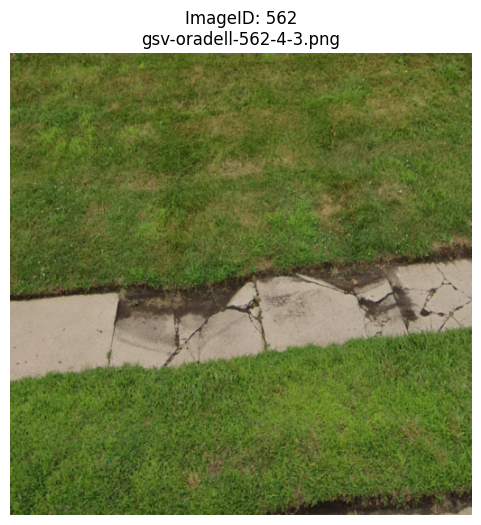

,MobilityAid,p_no,p_unsure,p_yes,decision,argmax
0,Manual wheelchair,0.209,0.210,0.581,yes,yes
1,Mobility scooter,0.321,0.179,0.499,unsure,yes
2,Motorized wheelchair,0.556,0.061,0.383,no,no
3,Walker,0.201,0.633,0.166,unsure,unsure
4,Walking cane,0.262,0.087,0.651,yes,yes


In [ ]:
# === One-image inference with per-head table (yes / unsure / no) — robust print ===
import numpy as np, pandas as pd, tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

CLASS_NAMES = ['no', 'unsure', 'yes']

# If you created head_names earlier, invert it to pretty MobilityAid
INV_HEAD_TO_AID = {v: k for k, v in head_names.items()} if 'head_names' in globals() \
                   else {h: h.replace('head_', '').replace('_', ' ').title() for h in HEADS}

def probs_to_label_index(p, tau=0.55, ent_tau=1.00):
    p = np.asarray(p, float)
    p = np.clip(p, 1e-9, 1.0); p = p / p.sum()
    ent = -(p * np.log(p)).sum()
    if p.max() < tau or ent > ent_tau:
        return 1  # 'unsure'
    return int(p.argmax())

def load_rgb_for_infer(path, img_size):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, (img_size, img_size), antialias=True)
    return img

def predict_one_image(image_id=None, tau=0.55, ent_tau=1.00, show=True):
    assert 'test_df' in globals(), "test_df not found — run the split/build cells first."
    assert 'model' in globals(), "model not found — train/load the model first."
    assert 'IMG_SIZE' in globals(), "IMG_SIZE not defined."

    # pick row
    if image_id is None:
        row = test_df.sample(1).iloc[0]
    else:
        hit = test_df[test_df['ImageID'] == int(image_id)]
        if len(hit) == 0:
            raise ValueError(f"ImageID {image_id} not in test_df.")
        row = hit.iloc[0]

    path = str(row['path'])
    img  = load_rgb_for_infer(path, IMG_SIZE)
    x    = tf.expand_dims(img, 0)

    preds = model(x, training=False)  # dict: head -> (1,3) logits

    records = []
    for h in HEADS:
        logits = preds[h].numpy()[0]
        probs  = tf.nn.softmax(logits).numpy()
        pred_i = probs_to_label_index(probs, tau=tau, ent_tau=ent_tau)
        records.append({
            "MobilityAid": INV_HEAD_TO_AID.get(h, h),
            "p_no": float(probs[0]),
            "p_unsure": float(probs[1]),
            "p_yes": float(probs[2]),
            "decision": CLASS_NAMES[pred_i],
            "argmax": CLASS_NAMES[int(np.argmax(probs))]
        })

    df_out = pd.DataFrame(records).sort_values("MobilityAid").reset_index(drop=True)

    if show:
        plt.figure(figsize=(6,6))
        plt.imshow(img.numpy()); plt.axis('off')
        plt.title(f"ImageID: {int(row['ImageID'])}\n{Path(path).name}")
        plt.show()

        # Format without .style to avoid the syntax issue
        df_show = df_out.copy()
        for c in ["p_no","p_unsure","p_yes"]:
            df_show[c] = df_show[c].map(lambda v: f"{v:.3f}")
        display(df_show[["MobilityAid","p_no","p_unsure","p_yes","decision","argmax"]])

    return int(row['ImageID']), path, df_out

# Example runs
_ = predict_one_image(image_id=None, tau=0.55, ent_tau=1.00)  # random test image
# _ = predict_one_image(image_id=456, tau=0.60, ent_tau=0.95)  # specific image

In [ ]:
# ===== 1) Load & normalize =====
import pandas as pd, numpy as np
from pathlib import Path

# Point this to your file if different:
CSV_PATH = CSV_DIR / 'image_selection.csv'  # or Path('/content/Project_Sidewalk_Data/image_selection.csv')

df = pd.read_csv(CSV_PATH)

# Keep only what we need
need = ['ImageID','MobilityAid','ImageType','Selection']
if not set(need).issubset(df.columns):
    raise ValueError(f'Missing required columns. Found: {list(df.columns)}; need: {need}')

df = df[need].dropna()

# normalize labels
df['Selection'] = (df['Selection'].astype(str).str.strip().str.lower()
                   .replace({'maybe':'unsure','cannot':'no','cannot_go':'no','n':'no','y':'yes'}))

# sanity: only keep known labels
df = df[df['Selection'].isin(['no','unsure','yes'])].copy()

print("Rows:", len(df))
print("Unique ImageIDs:", df['ImageID'].nunique())
print("Mobility aids:", sorted(df['MobilityAid'].dropna().unique().tolist()))
print("Image types:", sorted(df['ImageType'].dropna().unique().tolist()))

# ===== 2) Global label balance & by mobility aid =====
print("\n--- Global label counts ---")
print(df['Selection'].value_counts().reindex(['no','unsure','yes'], fill_value=0))

print("\n--- Label counts by MobilityAid ---")
lab_by_aid = (df
    .groupby(['MobilityAid','Selection'])
    .size().unstack(fill_value=0)
    .reindex(columns=['no','unsure','yes'], fill_value=0)
    .sort_index()
)
display(lab_by_aid)

print("\n--- Label proportions by MobilityAid ---")
display(lab_by_aid.div(lab_by_aid.sum(axis=1), axis=0).round(3))

print("\n--- Counts by ImageType (overall) ---")
lab_by_type = (df
    .groupby(['ImageType','Selection'])
    .size().unstack(fill_value=0)
    .reindex(columns=['no','unsure','yes'], fill_value=0)
    .sort_index()
)
display(lab_by_type)

# ===== 3) Per-(ImageID, MobilityAid) aggregation =====
tallies = (df
    .groupby(['ImageID','MobilityAid','Selection'])
    .size().unstack(fill_value=0)
    .reindex(columns=['no','unsure','yes'], fill_value=0)
    .reset_index()
    .rename(columns={'no':'votes_no','unsure':'votes_unsure','yes':'votes_yes'})
)

# soft proportions
s = tallies[['votes_no','votes_unsure','votes_yes']].sum(axis=1).replace(0, 1)
tallies[['p_no','p_unsure','p_yes']] = tallies[['votes_no','votes_unsure','votes_yes']].div(s, axis=0)

# majority with ties->unsure
def majority_label_row(r):
    d = {'no': r.votes_no, 'unsure': r.votes_unsure, 'yes': r.votes_yes}
    m = max(d.values()); winners = [k for k,v in d.items() if v==m]
    return 'unsure' if len(winners) > 1 else winners[0]
tallies['majority'] = tallies.apply(majority_label_row, axis=1)

print("\n--- Sample of per-(ImageID, MobilityAid) tallies ---")
display(tallies.head(10))

# ===== 4) How often does 'unsure' become the majority per aid? =====
unsure_rate = (tallies
    .groupby('MobilityAid')['majority']
    .apply(lambda s: (s=='unsure').mean())
    .sort_values(ascending=False)
    .rename('unsure_majority_rate')
)
print("\n--- Unsure as majority (rate) per MobilityAid ---")
display(unsure_rate.to_frame().round(3))

# ===== 5) Disagreement / uncertainty (entropy) ranking =====
def entropy(p):
    p = np.clip(np.asarray(p, float), 1e-9, 1.0)
    p = p / p.sum()
    return float(-(p*np.log(p)).sum())
tallies['entropy'] = tallies[['p_no','p_unsure','p_yes']].apply(lambda r: entropy(r.values), axis=1)

print("\n--- Top 15 most disagreed (highest entropy) per (ImageID, MobilityAid) ---")
display(tallies.sort_values('entropy', ascending=False).head(15))

# Also compute overall per-image soft labels (across all aids) if you want:
overall = (df
    .groupby(['ImageID','Selection'])
    .size().unstack(fill_value=0)
    .reindex(columns=['no','unsure','yes'], fill_value=0)
    .reset_index()
    .rename(columns={'no':'votes_no','unsure':'votes_unsure','yes':'votes_yes'})
)
s2 = overall[['votes_no','votes_unsure','votes_yes']].sum(axis=1).replace(0,1)
overall[['p_no','p_unsure','p_yes']] = overall[['votes_no','votes_unsure','votes_yes']].div(s2, axis=0)
overall['entropy'] = overall[['p_no','p_unsure','p_yes']].apply(lambda r: entropy(r.values), axis=1)

print("\n--- Overall (across all aids) label proportions (sample) ---")
display(overall.head(10))

# ===== 6) Save artifacts for inspection =====
OUT = Path('/content/analysis_outputs'); OUT.mkdir(exist_ok=True, parents=True)
lab_by_aid.to_csv(OUT/'label_counts_by_mobility_aid.csv')
lab_by_type.to_csv(OUT/'label_counts_by_image_type.csv')
tallies.to_csv(OUT/'per_imageid_mobilityaid_tallies.csv', index=False)
overall.to_csv(OUT/'per_imageid_overall_tallies.csv', index=False)

print(f"\nWrote: {OUT/'label_counts_by_mobility_aid.csv'}")
print(f"Wrote: {OUT/'label_counts_by_image_type.csv'}")
print(f"Wrote: {OUT/'per_imageid_mobilityaid_tallies.csv'}")
print(f"Wrote: {OUT/'per_imageid_overall_tallies.csv'}")

Rows: 9238
Unique ImageIDs: 52
Mobility aids: ['Manual wheelchair', 'Mobility scooter', 'Motorized wheelchair', 'Walker', 'Walking cane']
Image types: ['CurbRamp', 'NoCurbRamp', 'Obstacle', 'SurfaceProblem']

--- Global label counts ---
Selection
no        3515
unsure    1106
yes       4617
Name: count, dtype: int64

--- Label counts by MobilityAid ---


Selection,no,unsure,yes
MobilityAid,,,
Manual wheelchair,764,206,948
Mobility scooter,526,150,468
Motorized wheelchair,756,250,762
Walker,688,227,737
Walking cane,781,273,1702



--- Label proportions by MobilityAid ---


Selection,no,unsure,yes
MobilityAid,,,
Manual wheelchair,0.398,0.107,0.494
Mobility scooter,0.460,0.131,0.409
Motorized wheelchair,0.428,0.141,0.431
Walker,0.416,0.137,0.446
Walking cane,0.283,0.099,0.618



--- Counts by ImageType (overall) ---


...


--- Top 15 most disagreed (highest entropy) per (ImageID, MobilityAid) ---


Selection,ImageID,MobilityAid,votes_no,votes_unsure,votes_yes,p_no,p_unsure,p_yes,majority,entropy
46,2377,Mobility scooter,8,6,8,0.363636,0.272727,0.363636,unsure,1.090060
111,11707,Mobility scooter,9,6,7,0.409091,0.272727,0.318182,no,1.084363
81,4765,Mobility scooter,9,7,6,0.409091,0.318182,0.272727,no,1.084363
12,562,Motorized wheelchair,14,9,11,0.411765,0.264706,0.323529,no,1.082282
208,175408,Walker,12,8,12,0.375000,0.250000,0.375000,unsure,1.082196
193,145241,Walker,11,8,13,0.343750,0.250000,0.406250,yes,1.079588
188,141806,Walker,9,9,14,0.281250,0.281250,0.437500,yes,1.075209
67,3172,Motorized wheelchair,15,10,9,0.441176,0.294118,0.264706,no,1.072783
197,156512,Motorized wheelchair,9,10,15,0.264706,0.294118,0.441176,yes,1.072783
82,4765,Motorized wheelchair,15,10,9,0.441176,0.294118,0.264706,no,1.072783



--- Overall (across all aids) label proportions (sample) ---


Selection,ImageID,votes_no,votes_unsure,votes_yes,p_no,p_unsure,p_yes,entropy
0,262,101,24,53,0.567416,0.134831,0.297753,0.952424
1,456,45,35,98,0.252809,0.196629,0.550562,0.996032
2,562,88,27,63,0.494382,0.151685,0.353933,1.001948
3,631,45,30,103,0.252809,0.168539,0.578652,0.964296
4,669,74,16,88,0.415730,0.089888,0.494382,0.929717
5,997,124,14,39,0.700565,0.079096,0.220339,0.783265
6,1777,91,12,75,0.511236,0.067416,0.421348,0.888982
7,2022,118,17,43,0.662921,0.095506,0.241573,0.840003
8,2080,19,14,145,0.106742,0.078652,0.814607,0.605842
9,2377,36,28,114,0.202247,0.157303,0.640449,0.899564



Wrote: /content/analysis_outputs/label_counts_by_mobility_aid.csv
Wrote: /content/analysis_outputs/label_counts_by_image_type.csv
Wrote: /content/analysis_outputs/per_imageid_mobilityaid_tallies.csv
Wrote: /content/analysis_outputs/per_imageid_overall_tallies.csv
